<h3>Irrigation Water Requirement Prediction Using ML : Arif Miah </h3> 
<a href="https://www.kaggle.com/datasets/miadul/irrigation-water-requirement-prediction-dataset/data">Dataset</a> | 
<a href="https://www.kaggle.com/code/miadul/irrigation-water-requirement-prediction-using-ml">ipbynb</a>

Water Management in Chile Peppers and Plant Susceptibility to Phytophthora capsici and Development of Phytophthora Blight: A Review  
https://www.mdpi.com/2073-4395/15/12/2819?utm_source=chatgpt.com

In [1457]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score 
from xgboost import XGBRegressor

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('irrigation_prediction.csv')

In [1458]:
list_kolom = df.columns.tolist()
print(list_kolom)
df.head(2)

['Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare', 'Mulching_Used', 'Previous_Irrigation_mm', 'Region', 'Irrigation_Need']


,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,Clay,6.14,36.48,0.42,2.17,21.9,31.19,1167.70,4.01,1.97,Wheat,Vegetative,Rabi,Rainfed,Reservoir,4.73,Yes,1.98,South,Low
1,Silt,6.41,50.56,0.38,0.23,36.5,26.01,831.28,10.72,16.82,Maize,Flowering,Zaid,Canal,Groundwater,12.22,Yes,33.56,Central,Medium


In [1459]:
# print(df['Irrigation_Need'].unique())
print(df['Crop_Growth_Stage'].unique())

['Vegetative' 'Flowering' 'Harvest' 'Sowing']


In [1460]:
print(df['Crop_Type'].unique())

['Wheat' 'Maize' 'Cotton' 'Rice' 'Sugarcane' 'Potato']


In [1461]:
print(df['Irrigation_Need'].unique())

['Low' 'Medium' 'High']


In [1462]:
df_data = df[['Soil_Moisture','Temperature_C','Humidity','Rainfall_mm','Crop_Growth_Stage','Previous_Irrigation_mm','Irrigation_Need']]
print(df_data.columns)

Index(['Soil_Moisture', 'Temperature_C', 'Humidity', 'Rainfall_mm',
       'Crop_Growth_Stage', 'Previous_Irrigation_mm', 'Irrigation_Need'],
      dtype='object')


In [1463]:
df['Crop_Growth_Stage'] = df_data['Crop_Growth_Stage'].map({
    'Vegetative' : 0,
    'Flowering' : 1,
    'Harvest' : 2,
    'Sowing' : 3,
}).astype(int)

df['Irrigation_Need'] = df_data['Irrigation_Need'].map({
    'Medium' : 1,
    'Low' : 0,
    'High' : 2,
}).astype(int)

df.head(2)

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,Clay,6.14,36.48,0.42,2.17,21.9,31.19,1167.70,4.01,1.97,Wheat,0,Rabi,Rainfed,Reservoir,4.73,Yes,1.98,South,0
1,Silt,6.41,50.56,0.38,0.23,36.5,26.01,831.28,10.72,16.82,Maize,1,Zaid,Canal,Groundwater,12.22,Yes,33.56,Central,1


In [1464]:
print("Jumlah data:", len(df_data))

Jumlah data: 10000


In [1465]:
df['Previous_Irrigation_mm_diff'] = df['Previous_Irrigation_mm'].diff()
df = df.dropna()

In [1466]:
# df['lag1'] = df['Previous_Irrigation_mm'].shift(1)
# df['lag2'] = df['Previous_Irrigation_mm'].shift(2)
# df['lag3'] = df['Previous_Irrigation_mm'].shift(3)
# df['lag4'] = df['Previous_Irrigation_mm'].shift(4)
# df['lag5'] = df['Previous_Irrigation_mm'].shift(5)
# df['lag6'] = df['Previous_Irrigation_mm_diff'].shift(6)
# df['lag7'] = df['Previous_Irrigation_mm_diff'].shift(7)
# df['lag8'] = df['Previous_Irrigation_mm_diff'].shift(8)

In [1467]:
# rolling mean untuk bantu baca pola lokal
# df['rolling_mean_3'] = df['Previous_Irrigation_mm'].rolling(3).mean()
# df['rolling_mean_5'] = df['Previous_Irrigation_mm'].rolling(5).mean()
# df['rolling_mean_10'] = df['Previous_Irrigation_mm'].rolling(10).mean()

In [1468]:
# df['rolling_std_5'] = df['Previous_Irrigation_mm_diff'].rolling(5).std()
# 🔥 perubahan cepat (momentum)
# df['diff2'] = df['Previous_Irrigation_mm_diff'].diff(1)

# 🔥 max/min lokal
# df['rolling_max_5'] = df['Previous_Irrigation_mm_diff'].rolling(5).max()
# df['rolling_min_5'] = df['Previous_Irrigation_mm_diff'].rolling(5).min()

In [1469]:
df = df.dropna().reset_index(drop=True)

In [1470]:
X = df[[
    'Crop_Growth_Stage'
    'Soil_Moisture',
    'Temperature_C',
    'Humidity',
    'Rainfall_mm',
    'Previous_Irrigation_mm',
    # 'lag1',
    # 'lag2',
    # 'lag3',
    # 'lag4',
    # 'lag5',
    # 'lag6',
    # 'lag7',
    # 'lag8',
    # 'rolling_mean_3','rolling_mean_5','rolling_mean_10',
    # 'rolling_std_5','rolling_max_5','rolling_min_5',
    # 'diff2'
]]

In [1471]:

X = df.drop("Irrigation_Need", axis=1)
# y = df['Previous_Irrigation_mm_diff'] 
y = df["Irrigation_Need"]
print("\nUkuran data:")
print("X shape:", X.shape)
print("y shape:", y.shape)


Ukuran data:
X shape: (9999, 20)
y shape: (9999,)


In [1472]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("\nData train:", X_train.shape, y_train.shape)
print("Data test :", X_test.shape, y_test.shape)


Data train: (7999, 20) (7999,)
Data test : (2000, 20) (2000,)


In [1473]:
# print(df.dtypes)

In [1474]:
# model = XGBRegressor(
#     n_estimators=100,
#     learning_rate=0.1,
#     max_depth=8,
#     min_child_weight=3,
#     subsample=0.9,
#     colsample_bytree=0.9,
#     gamma=0.1,
#     reg_alpha=0.1,
#     reg_lambda=1,
#     objective='reg:squarederror',
#     random_state=42
# )

# model.fit(
#     X_train, y_train,
#     eval_set=[(X_test, y_test)],
#     verbose=False
# )

In [1475]:
# y_pred = model.predict(X_test)

In [1476]:
# # =========================================================
# # 11. EVALUASI
# # =========================================================
# mse = mean_squared_error(y_test, y_pred)
# rmse = np.sqrt(mse)
# mae = mean_absolute_error(y_test, y_pred)
# r2 = r2_score(y_test, y_pred)

# print("\nHasil Evaluasi XGBoost")
# print("MSE  :", mse)
# print("RMSE :", rmse)
# print("MAE  :", mae)
# print("R2   :", r2)

In [1477]:
# # =========================================================
# # 12. VISUALISASI ACTUAL VS PREDICTION
# # =========================================================
# plt.figure(figsize=(12, 6))
# plt.plot(y_test.values, label='Actual')
# plt.plot(y_pred, label='Prediction')
# plt.title("XGBoost Prediction")
# plt.xlabel("Index")
# plt.ylabel("Irrigation")
# plt.legend()
# plt.show()

In [1478]:
# # =========================================================
# # 13. FEATURE IMPORTANCE
# # =========================================================
# importance_df = pd.DataFrame({
#     'feature': X.columns,
#     'importance': model.feature_importances_
# }).sort_values(by='importance', ascending=False)

# print("\nFeature Importance:")
# print(importance_df)

# plt.figure(figsize=(10, 6))
# plt.barh(importance_df['feature'], importance_df['importance'])
# plt.gca().invert_yaxis()
# plt.title("Feature Importance - XGBoost")
# plt.xlabel("Importance")
# plt.show()

Uji coba Regression, Classifier

In [1479]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet 
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [1480]:
df_data = df[['Crop_Growth_Stage','Soil_Moisture','Temperature_C','Humidity','Rainfall_mm','Previous_Irrigation_mm','Irrigation_Need']]
print(df_data.columns)
# data = pd.DataFrame({
#     'luas (m2)' : [50,60,70,80,90,100],
#     'Harga (juta)' : [150,180,200,220,240,270]
# })
# print(data.columns)

Index(['Crop_Growth_Stage', 'Soil_Moisture', 'Temperature_C', 'Humidity',
       'Rainfall_mm', 'Previous_Irrigation_mm', 'Irrigation_Need'],
      dtype='object')


In [ ]:
df_data.head(5)
# data.head(2)
df['Irrigation_Need'] = df['Irrigation_Need'].map({
    'Low': 0,
    'Medium': 1,
    'High': 2
})

In [1482]:
print(df['Irrigation_Need'].head())
print(df['Irrigation_Need'].unique())

0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: Irrigation_Need, dtype: float64
[nan]


In [1483]:
df_data.head(5)

,Crop_Growth_Stage,Soil_Moisture,Temperature_C,Humidity,Rainfall_mm,Previous_Irrigation_mm,Irrigation_Need
0,1,50.56,36.50,26.01,831.28,33.56,1
1,2,40.07,41.83,76.41,1844.45,34.62,0
2,3,12.75,37.22,43.32,306.26,84.03,1
3,3,18.58,22.38,86.44,1875.63,60.86,1
4,3,20.50,33.34,62.51,402.92,7.33,1


Split Data

In [1484]:
X = df[[
    'Crop_Growth_Stage',
    'Soil_Moisture',
    'Temperature_C',
    'Humidity',
    'Rainfall_mm',
    'Previous_Irrigation_mm'
]] 

y = df[['Irrigation_Need']]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)
print("Ukuran data:", df.shape) 

Ukuran data: (9999, 21)


Traninng Model

<h6>Regresisi Model</h6>

In [1487]:
models = {
    "LinearRegression"  : LinearRegression(),
    "Ridge"             : Ridge(alpha=1),
    "Lasso"             : Lasso(alpha=1),
    "XGBRegressor"      : XGBRegressor(n_estimators=48,learning_rate=0.05,max_depth=6,subsample=0.8,colsample_bytree=0.8,objective='reg:squarederror',random_state=1),
}
results = {}

In [1486]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"\n{name}")
    print("5 prediksi pertama:", y_pred[:5])

    results[name] = {
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }

ValueError: Input y contains NaN.

In [ ]:
print("\nEvaluasi Model:")
hasil_tabel = pd.DataFrame(results).T[['MSE', 'RMSE', 'MAE', 'R2']]
print(hasil_tabel.round(6))


Evaluasi Model:
                       MSE      RMSE       MAE        R2
LinearRegression  0.186219  0.431531  0.351950  0.376214
Ridge             0.186219  0.431531  0.351953  0.376213
Lasso             0.252616  0.502609  0.450402  0.153802
XGBRegressor      0.118817  0.344698  0.275089  0.601995


<h6>Classification Model</h6>

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
df_data.head(5)

,Crop_Growth_Stage,Soil_Moisture,Temperature_C,Humidity,Rainfall_mm,Previous_Irrigation_mm,Irrigation_Need
0,1,50.56,36.50,26.01,831.28,33.56,Medium
1,2,40.07,41.83,76.41,1844.45,34.62,Low
2,3,12.75,37.22,43.32,306.26,84.03,Medium
3,3,18.58,22.38,86.44,1875.63,60.86,Medium
4,3,20.50,33.34,62.51,402.92,7.33,Medium


In [ ]:
print(df_data['Irrigation_Need'].astype(str).unique())

['Medium' 'Low' 'High']


In [ ]:
print(df_data['Irrigation_Need'].head())
print("Jumlah NaN:", df_data['Irrigation_Need'].isna().sum())
print("Total data:", len(df_data))

0    Medium
1       Low
2    Medium
3    Medium
4    Medium
Name: Irrigation_Need, dtype: object
Jumlah NaN: 0
Total data: 9999


In [ ]:
df_data['Crop_Growth_Stage'] = df_data['Crop_Growth_Stage'].map({
    'Vegetative' : 0,
    'Flowering' : 1,
    'Harvest' : 2,
    'Sowing' : 3,
})
df['Irrigation_Need'] = df['Irrigation_Need'].map({
    'Low': 0,
    'Medium': 1,
    'High': 2
})
df = df.dropna(subset=['Irrigation_Need'])
df['Irrigation_Need'] = df['Irrigation_Need'].astype(int)

In [ ]:
# Fitur dan target
# Siapkan fitur dan target
X = df_data[['Crop_Growth_Stage','Soil_Moisture', 'Temperature_C', 'Humidity', 'Rainfall_mm']]
y = df_data['Irrigation_Need']
print("Label unik:", y.unique())
print("Tipe data y:", y.dtype)
print("Ukuran data akhir:", df_data.shape)

Label unik: ['Medium' 'Low' 'High']
Tipe data y: object
Ukuran data akhir: (9999, 7)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
cmodels = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "RandomForestClassifier": RandomForestClassifier(n_estimators=200, random_state=1),
    "XGBClassifier": XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='mlogloss',
        random_state=1
    )
}

In [ ]:
cresults ={}
for name, model in cmodels.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    cresults[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "F1-Score": f1_score(y_test, y_pred, average='weighted'),
        "y_pred": y_pred
    }
    print(name)
    print("unique y_test :", pd.Series(y_test).unique())
    print("unique y_pred :", pd.Series(y_pred).unique()[:10])

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
chasil_tabel = pd.DataFrame(cresults).T[['Accuracy', 'Precision', 'Recall', 'F1-Score']]
print("Evaluasi Model Klasifikasi:")
print(chasil_tabel.round(4))

Evaluasi Model Klasifikasi:
                       Accuracy Precision  Recall  F1-Score
LogisticRegression       0.6755  0.665031  0.6755  0.662178
RandomForestClassifier   0.7015  0.695134  0.7015  0.697015
XGBClassifier            0.7175  0.712022  0.7175  0.712547


In [ ]:
best_model = cmodels["XGBClassifier"]
y_pred_best = best_model.predict(X_test)

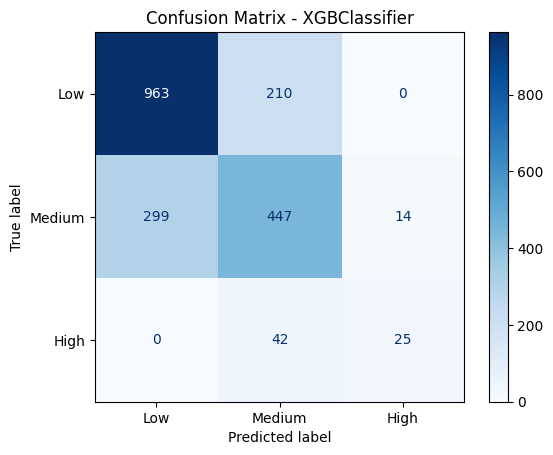

In [ ]:
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low', 'Medium', 'High'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - XGBClassifier")
plt.show()

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_best, target_names=['Low', 'Medium', 'High']))

              precision    recall  f1-score   support

         Low       0.76      0.82      0.79      1173
      Medium       0.64      0.59      0.61       760
        High       0.64      0.37      0.47        67

    accuracy                           0.72      2000
   macro avg       0.68      0.59      0.63      2000
weighted avg       0.71      0.72      0.71      2000

